In [1]:
import matplotlib.pyplot as plt
from pytorch3dunet.datasets.dsb import TIF_txt_Dataset
import numpy as np
from model_ranking import get_random_colors

INFO: P [MainThread] 2026-08-08 13:53:26,451 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
from typing import Dict, Any

transformer_config: Dict[Any, Any] = {
    "raw": [
        {"name": "CropToFixed", "size": [256,256]},
        {"name": "PercentileNormalizer"},
        #{"name": "FixedClipping", "max_value": 2},
        #{"name": "ToTensor", "expand_dims": True},
    ],
    "label": [
        {"name": "CropToFixed", "size": [256,256]},
        {"name": "Relabel"},
        #{"name": "BlobsToMask", "append_label": True},
        #{"name": "ToTensor", "expand_dims": True},
    ]
}

# BBBC039

In [5]:
BC_dataset = TIF_txt_Dataset(
    image_dir="/g/kreshuk/talks/data/BBBC039/images",
    mask_dir="/g/kreshuk/talks/data/BBBC039/instance_annotations/instance_labels",
    phase='train',
    transformer_config=transformer_config,
    filenames_path="/g/kreshuk/talks/data/BBBC039/train.txt",
    global_norm=True,
    percentiles=[5,98]
)
print(f"Dataset length: {len(BC_dataset)}")

Dataset length: 100


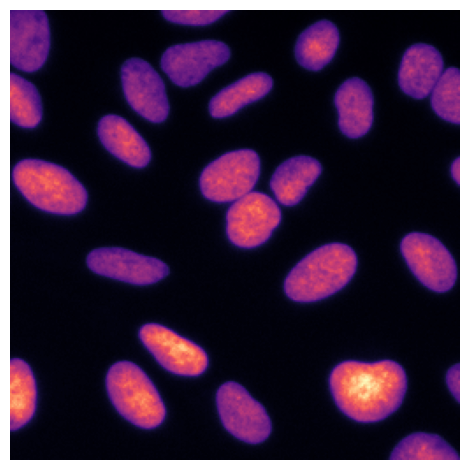

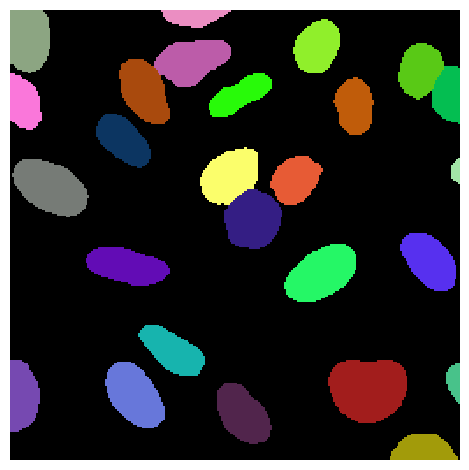

In [7]:
i = 6
target = "BBBC039"
raw, label = BC_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma')
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# Hoechst

In [8]:
from pytorch3dunet.datasets.dsb import Hoechst_Dataset

In [14]:
H_dataset = Hoechst_Dataset(
    image_dir="/g/kreshuk/talks/data/Hoechst/test_nuclei/images/png",
    mask_dir="/g/kreshuk/talks/data/Hoechst/test_nuclei/annotations",
    phase='train',
    transformer_config=transformer_config,
    global_norm=False,
    percentiles=[5,98]
)
print(f"Dataset length: {len(H_dataset)}")

Dataset length: 10


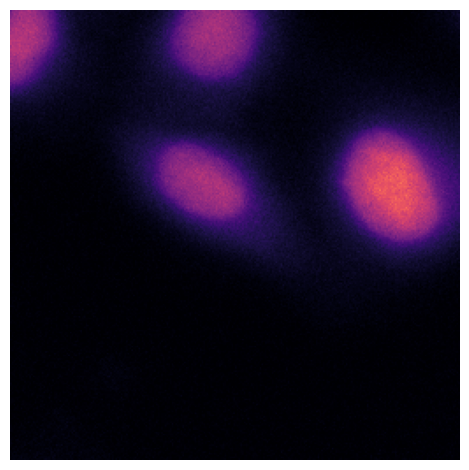

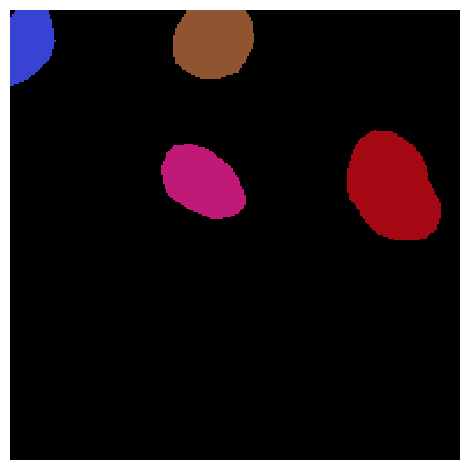

In [20]:
i = 6
target = "Hoechst"
raw, label = H_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# HeLaCytoNuc

In [21]:
from pytorch3dunet.datasets.dsb import HeLaNuc_Dataset

In [23]:
HN_dataset = HeLaNuc_Dataset(
    image_dir="/g/kreshuk/talks/data/HeLaCytoNuc/test/images",
    mask_dir="/g/kreshuk/talks/data/HeLaCytoNuc/test/nuclei_masks",
    phase='train',
    transformer_config=transformer_config,
    global_norm=False,
    percentiles=[5,99.8]
)
print(f"Dataset length: {len(HN_dataset)}")

Dataset length: 267


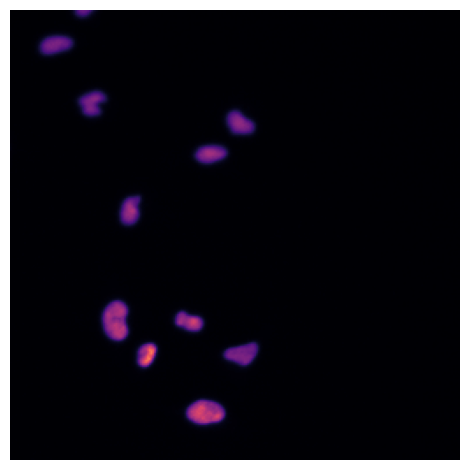

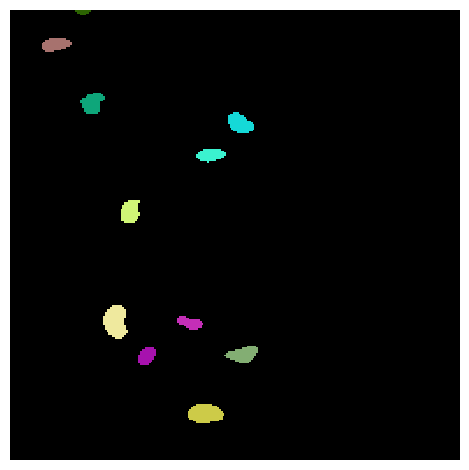

In [24]:
i = 6
target = "HeLaNuc"
raw, label = HN_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# S-BIAD895

In [25]:
from pytorch3dunet.datasets.dsb import Standard_TIF_Dataset

In [27]:
SB895_dataset = Standard_TIF_Dataset(
    image_dir="/g/kreshuk/talks/data/S-BIAD895/ZeroCostDL4Mic/Stardist_v2/Stardist/Train/Raw",
    mask_dir="/g/kreshuk/talks/data/S-BIAD895/ZeroCostDL4Mic/Stardist_v2/Stardist/Train/Masks",
    phase='train',
    transformer_config=transformer_config,
    global_norm=False,
    percentiles=[5,98]
)

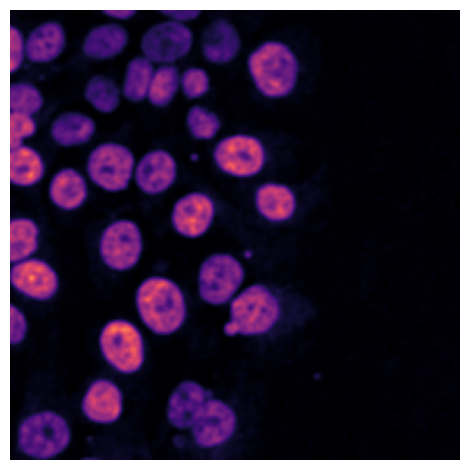

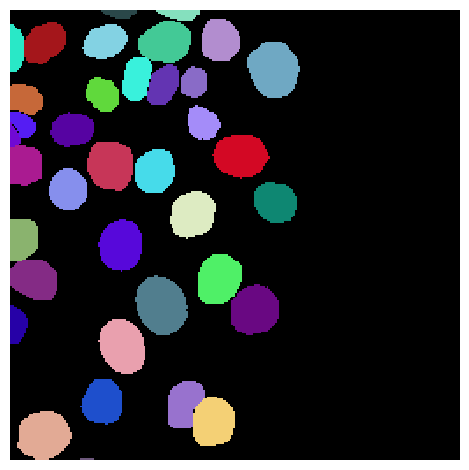

In [28]:
i = 6
target = "S_BIAD895"
raw, label = SB895_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# S-BIAD1410

In [29]:
from pytorch3dunet.datasets.dsb import S_BIAD1410_Dataset

In [30]:
slice_builder_cfg = {
    'name': 'SliceBuilder',
    'patch_shape': [1, 256, 256],
    'stride_shape': [1, 256, 256],
    'halo_shape': [0,0,0],
}

In [32]:
SB1410_dataset = S_BIAD1410_Dataset(
    img_path='/g/kreshuk/talks/data/S-BIAD1410/cardioblast_nuclei/cardioblast_nuclei_test/cardioblast_nuclei_20200121_e3/cardioblast_nuclei_20200121_e3.tif',
    mask_path='/g/kreshuk/talks/data/S-BIAD1410/cardioblast_nuclei/cardioblast_nuclei_test/cardioblast_nuclei_20200121_e3/cardioblast_nuclei_20200121_e3_mask.tif',
    roi=None,
    phase="train",
    slice_builder_config=slice_builder_cfg,
    transformer_config=transformer_config,
    global_normalization=True,
    global_percentiles=[5,98]
)

2026-08-08 14:12:10,367 [MainThread] INFO DSB2018Dataset - Calculating mean and std of the raw data...
2026-08-08 14:12:12,273 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': [1, 256, 256], 'stride_shape': [1, 256, 256], 'halo_shape': [0, 0, 0]}
2026-08-08 14:12:12,278 [MainThread] INFO DSB2018Dataset - Number of patches: 1400


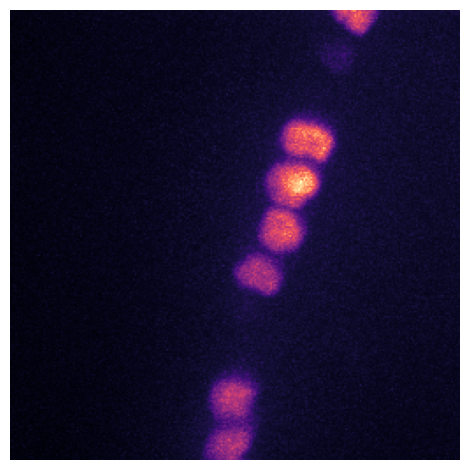

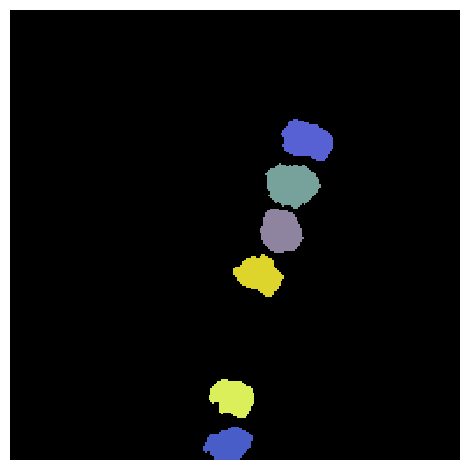

In [35]:
i = 200
target = "S_BIAD1410"
raw, label = SB1410_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# DSB2018

In [36]:
DSB_dataset = Standard_TIF_Dataset(
    image_dir="/g/kreshuk/data/dsb2018_fluorescence/train/images",
    mask_dir="/g/kreshuk/data/dsb2018_fluorescence/train/masks",
    phase='train',
    transformer_config=transformer_config,
    global_norm=False,
    percentiles=[5,98]
)

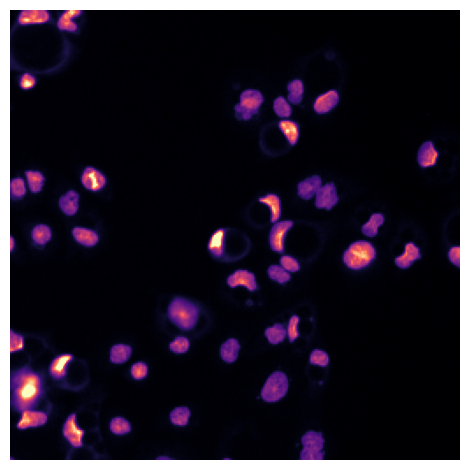

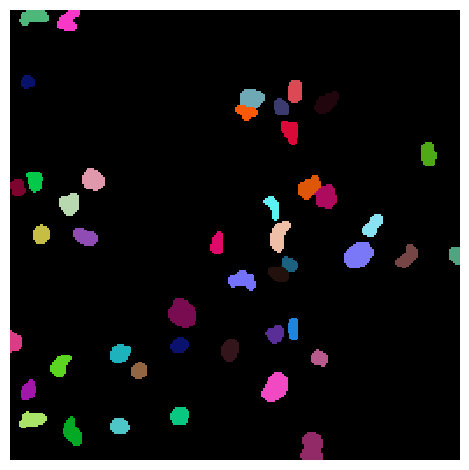

In [38]:
i = 70
target = "DSB2018"
raw, label = DSB_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# SBIAD1196

In [67]:
from pytorch3dunet.datasets.hdf5 import StandardHDF5Dataset

In [68]:
transformer_config = {
    "raw": [
        #{"name": "CropToFixed", "size": [256,256]},
        {"name": "PercentileNormalizer"},
        {"name": "ToTensor", "expand_dims": True},
    ],
    "label": [
        {"name": "ToTensor", "expand_dims": True},
    ]
}
filter_slice_builder_cfg = {
    'name': 'FilterSliceBuilder',
    'patch_shape': [1, 200, 200],
    'stride_shape': [2, 200, 200],
    'halo_shape': [0,32,32],
    'threshold': 0.005,
    'slack_acceptance': 0,
}
dir_path = "/g/kreshuk/talks/data/S-BIAD1196/SELMA3D_training_annotated/shannel_cells/h5/val/patchvolume_008.h5"

In [69]:
SB1196_dataset = StandardHDF5Dataset(
    file_path=dir_path,
    roi=None,
    phase="val",
    slice_builder_config=filter_slice_builder_cfg,
    transformer_config=transformer_config,
    global_normalization=True,
    global_percentiles=[5,98]
)


2026-08-08 15:11:42,735 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: [1, 200, 200] and volume_shape: (200, 200, 200)
2026-08-08 15:11:42,736 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 2157.513402375, global std: 1642.9237907019242
2026-08-08 15:11:43,457 [MainThread] INFO Dataset - Slice builder config: {'name': 'FilterSliceBuilder', 'patch_shape': [1, 200, 200], 'stride_shape': [2, 200, 200], 'halo_shape': [0, 32, 32], 'threshold': 0.005, 'slack_acceptance': 0}
2026-08-08 15:11:43,461 [MainThread] INFO Dataset - Filtering slices...
2026-08-08 15:11:44,417 [MainThread] INFO HDF5Dataset - Number of patches: 99


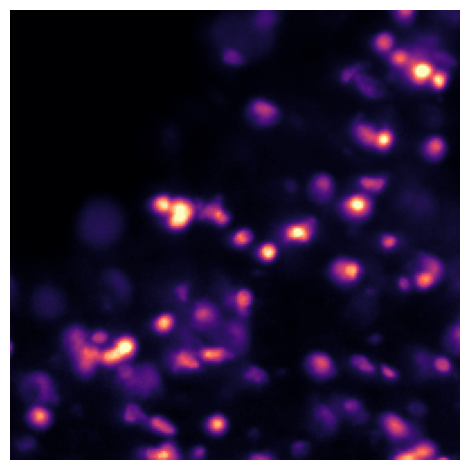

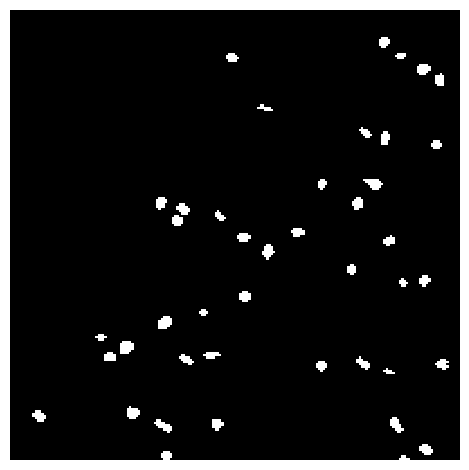

In [71]:
i = 20
target = "S_BIAD1196"
raw, label = SB1196_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap='grey', interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

# S_BIAD634

In [74]:
SB634_dataset = TIF_txt_Dataset(
    image_dir="/g/kreshuk/talks/data/S-BIAD634/dataset/rawimages",
    mask_dir="/g/kreshuk/talks/data/S-BIAD634/dataset/groundtruth",
    phase='train',
    transformer_config=transformer_config,
    filenames_path="/g/kreshuk/talks/data/S-BIAD634/dataset/test.txt",
    global_norm=False,
    percentiles=[5,98]
)

<tifffile.TiffFile 'otherspecimen_3.tif'> shaped series shape does not match page shape


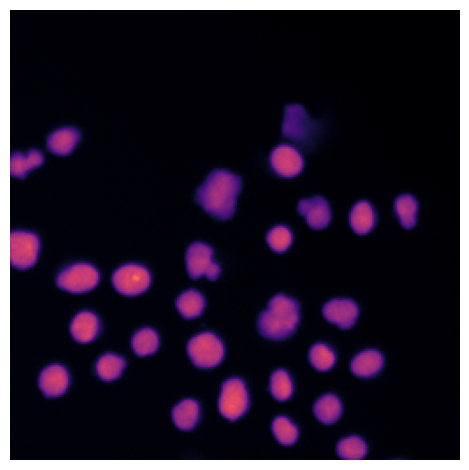

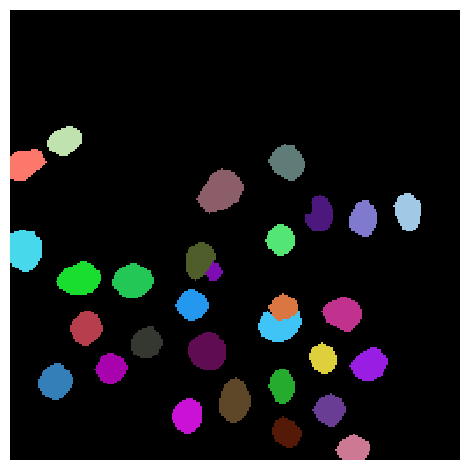

In [78]:
i = 20
target = "S_BIAD634"
raw, label = SB634_dataset[i]


_ = plt.imshow(raw.squeeze(), cmap='magma', vmin=0, vmax=2)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_raw.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

_ = plt.imshow(label.squeeze(), cmap=get_random_colors(label), interpolation="nearest")
_ = plt.axis("off")
plt.tight_layout()
plt.savefig(f"/g/kreshuk/talks/model_ranking/notebooks/thesis/nuclei/example_data/{target}_inst_label.png", bbox_inches="tight", pad_inches=0, dpi=500)
plt.show()

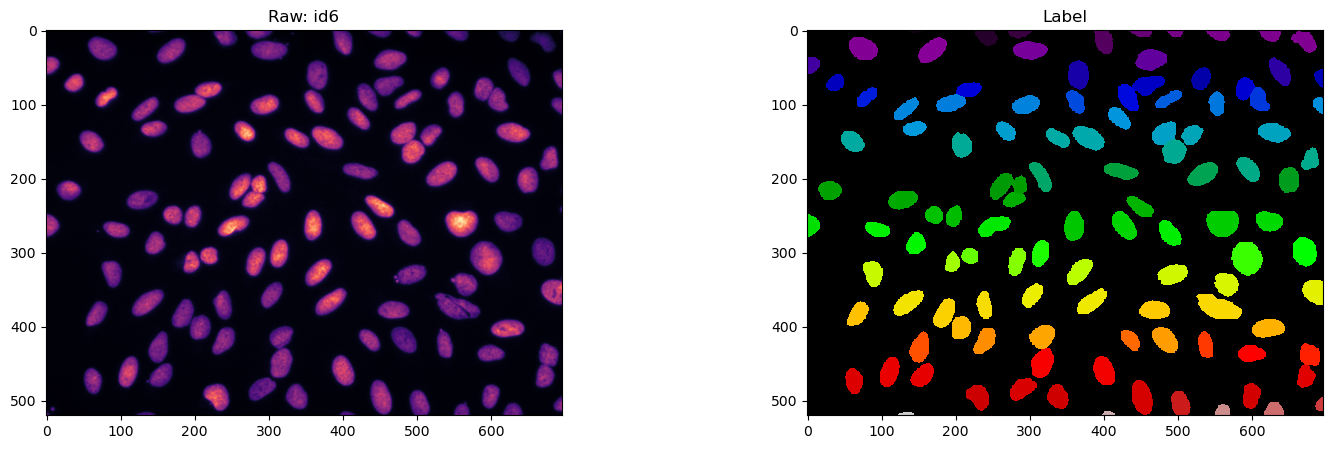

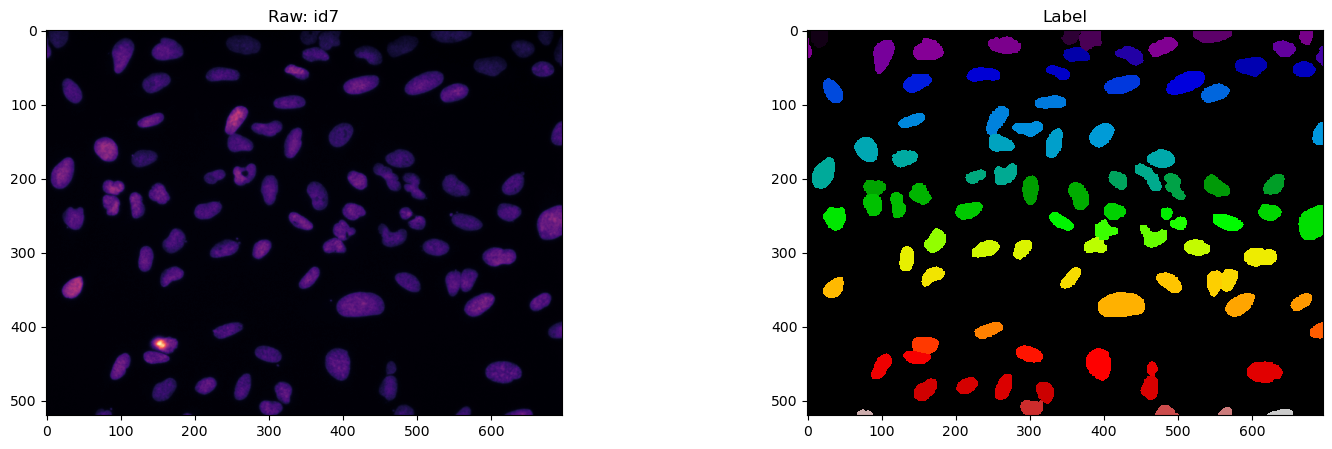

In [17]:
for i in range(6, 8):
    raw, label = dataset[i]
    _, axs = plt.subplots(1, 2, figsize=(18, 5))
    axs[0].imshow(raw[0].squeeze(), cmap="magma")
    axs[0].set_title(f"Raw: id{i}")
    axs[1].imshow(label[0].squeeze(), interpolation="nearest", cmap="nipy_spectral")
    axs[1].set_title("Label")
    plt.show()